# 01 - Data Audit

**AI-Powered Construction Finishing Cost Estimation System**

This notebook performs the Phase 1 (project audit) and Phase 2 (dataset audit) work:
it inventories what existed before this pipeline was built, documents a critical
finding about the provenance of the `All data/` folder, loads every raw source
file, and profiles it (shape, dtypes, missing values, duplicates, invalid prices,
categorical vocabularies, and price distributions).

Nothing in this notebook modifies any raw file. It only reads `data/raw/*.csv`
(copies of the true source files -- see Section 3) and writes a report to
`reports/01_data_audit_report.md`.

## 1. Setup

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def find_project_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "src").is_dir() and (parent / "data").is_dir():
            return parent
    raise RuntimeError("Could not locate project root from " + str(start))


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

PROJECT_ROOT

Matplotlib is building the font cache; this may take a moment.


WindowsPath('F:/Instant/DataAnalysis/Gradution Project/All data/_staging')

In [2]:
from src.config import RAW_DATA_DIR, RAW_CATEGORY_FILES, REPORTS_DIR
from src.data_processing.load_raw import load_all_raw, load_raw_category
from src.data_processing.audit import profile_dataframe, numeric_outlier_bounds
from src.data_processing.cleaning import flag_price_outliers

RAW_CATEGORY_FILES

{'ceilings_gypsum.csv': 'Ceilings',
 'doors.csv': 'Doors',
 'electrical_basic.csv': 'Electrical Basic',
 'electrical_finishing.csv': 'Electrical Finishing',
 'flooring.csv': 'Flooring',
 'paints.csv': 'Paints',
 'plumbing_basic.csv': 'Plumbing Basic',
 'sanitary_ware.csv': 'Sanitary Ware',
 'labor_and_auxiliary.csv': 'Labor and Auxiliary'}

## 2. Project Inventory (Phase 1)

Before writing any pipeline code, the full workspace was inspected manually
(raw folders, notebooks, derived CSVs). Findings:

| Location | Contents |
|---|---|
| `ceilings_gypsum/`, `Doors/`, `electrical_basic/`, `electrical_finishing/`, `Flooring/`, `Paints/`, `plumbing/`, `sanitary_ware/` | One working folder per category. Each contains the **true raw** product CSV plus a notebook (`*.ipynb`) that cleans it, adds a placeholder `Estimated_Total_Cost` (using a hard-coded `Apartment_Area_m2 = 100`), and exports a `*_model_ready` / `*_ml_ready` CSV. |
| `labor_and_auxiliary/` | A single small (9-row) hand-curated CSV of labor and auxiliary-material costs. No notebook. |
| `All data/` | A **consolidated snapshot**, mostly containing the *already processed* outputs of the notebooks above (see critical finding below), plus two further artifacts: `master_finishing_products.csv` (a prior attempt at a unified master dataset, 6,487 rows) and `flooring_ml.csv` (a baseline price-prediction ML-ready subset for flooring only). |
| `All data.zip` | A zip snapshot of `All data/`. Not used. |

**What already existed:** per-category cleaning notebooks, category-specific
`Quantity_Rule` / `Rule_Value` requirement logic, a first master-dataset
consolidation attempt, and (in the notebooks' own closing markdown cells,
several written in Arabic) an explicit statement of the *same* end-to-end
goal as this project: combine categories into one master dataset, generate
apartment scenarios from user inputs (area, rooms, bathrooms, budget,
finishing level), and train one scikit-learn model.

**What needed to be (re)built:** a documented, reproducible cleaning +
master-dataset pipeline built from the *true* raw files (rather than
inheriting undocumented steps), the apartment-scenario / training-dataset
generation logic (the previous notebooks only ever used a hard-coded
100 sqm placeholder), leakage-safe model training/comparison, and
deployment.

All of this prior work is preserved untouched in `data/previous_work/`
(csvs + notebooks) and used only as reference.

## 3. Critical Finding: `All data/` is not raw data

Before trusting `All data/*.csv` as the source of truth, every file in it was
compared byte-for-byte (size + modified-time) against the candidate raw and
processed files sitting in each category's own working folder.

| `All data/` file | Identical to (same size + mtime) | Conclusion |
|---|---|---|
| `ceilings_gypsum.csv` | `ceilings_gypsum/ceilings_gypsum_model.csv` | Already model-ready output |
| `doors.csv` | `Doors/doors_model_ready.csv` | Already model-ready output |
| `flooring.csv` | `Flooring/flooring_model_ready.csv` | Already model-ready output |
| `flooring_ml.csv` | `Flooring/flooring_ml_ready.csv` | Baseline price-model ML set |
| `paints.csv` | `Paints/paints_model.csv` | Already model-ready output |
| `electrical_basic.csv` | *(no exact match; has `Estimated_Total_Cost`, `Finishing_Category` columns not present in the raw file)* | Already feature-engineered |
| `electrical_finishing.csv` | *(same pattern)* | Already feature-engineered |
| `plumbing_basic.csv` | *(reduced to the shared master-model column set)* | Master-model-ready subset |
| `sanitary_ware.csv` | *(reduced to the shared master-model column set)* | Master-model-ready subset |
| `labor_and_auxiliary.csv` | `labor_and_auxiliary/labor_and_auxiliary.csv` | Genuinely raw (no notebook exists for it) |
| `master_finishing_products.csv` | -- | A previous master-dataset consolidation attempt (6,487 rows = exact sum of the 9 categories' model-ready row counts) |

**Decision (documented per project rules):** the *true* raw/source files are
the plain CSVs inside each category's own working folder (e.g.
`Flooring/flooring.csv`, 1,011 rows, 17 columns) -- not the `All data/`
versions, which are already cleaned and partially feature-engineered with an
undocumented, hard-coded placeholder apartment area. `data/raw/` in this
project therefore contains copies of those true raw files. `All data/`
itself was never modified.

## 4. Load Raw Source Data

In [3]:
raw = load_all_raw()
shape_table = pd.DataFrame(
    {"Rows": {k: v.shape[0] for k, v in raw.items()},
     "Columns": {k: v.shape[1] for k, v in raw.items()}}
)
shape_table.loc["TOTAL"] = [shape_table["Rows"].sum(), np.nan]
shape_table

,Rows,Columns
ceilings_gypsum.csv,260.0,22.0
doors.csv,1781.0,21.0
electrical_basic.csv,938.0,19.0
electrical_finishing.csv,555.0,19.0
flooring.csv,1011.0,19.0
paints.csv,165.0,23.0
plumbing_basic.csv,229.0,19.0
sanitary_ware.csv,1669.0,19.0
labor_and_auxiliary.csv,9.0,13.0
TOTAL,6617.0,NaN


## 5. Per-Category Profile (Phase 2)

In [4]:
profiles = {filename: profile_dataframe(df, filename) for filename, df in raw.items()}

for filename, profile in profiles.items():
    print(profile.to_markdown())

### ceilings_gypsum.csv

- Rows: **260**, Columns: **22**
- Duplicate rows: **11**
- Price_EGP: min=180, median=262, mean=262, max=349
- Price_EGP missing: **0**, Price_EGP <= 0: **0**
- Missing values: none

### doors.csv

- Rows: **1781**, Columns: **21**
- Duplicate rows: **26**
- Price_EGP: min=3201, median=6154, mean=7609, max=14497
- Price_EGP missing: **0**, Price_EGP <= 0: **0**
- Missing values: none

### electrical_basic.csv

- Rows: **938**, Columns: **19**
- Duplicate rows: **47**
- Price_EGP: min=58, median=2600, mean=2242, max=3098
- Price_EGP missing: **0**, Price_EGP <= 0: **0**
- Missing values: none

### electrical_finishing.csv

- Rows: **555**, Columns: **19**
- Duplicate rows: **16**
- Price_EGP: min=55, median=1705, mean=1534, max=3491
- Price_EGP missing: **0**, Price_EGP <= 0: **0**
- Missing values: none

### flooring.csv

- Rows: **1011**, Columns: **19**
- Duplicate rows: **7**
- Price_EGP: min=169, median=547, mean=533, max=947
- Price_EGP missing: **0**, Pr

## 6. Consolidated Audit Table

In [5]:
summary_rows = []
for filename, p in profiles.items():
    summary_rows.append({
        "File": filename,
        "Category": RAW_CATEGORY_FILES[filename],
        "Rows": p.n_rows,
        "Columns": p.n_cols,
        "Duplicate_Rows": p.n_duplicates,
        "Price_Missing": p.n_price_missing,
        "Price_LE_Zero": p.n_price_le_zero,
        "Price_Min": p.price_stats.get("min"),
        "Price_Median": p.price_stats.get("50%"),
        "Price_Max": p.price_stats.get("max"),
    })

audit_summary = pd.DataFrame(summary_rows)
audit_summary

,File,Category,Rows,Columns,Duplicate_Rows,Price_Missing,Price_LE_Zero,Price_Min,Price_Median,Price_Max
0,ceilings_gypsum.csv,Ceilings,260,22,11,0,0,180.0,262.5,349.0
1,doors.csv,Doors,1781,21,26,0,0,3201.0,6154.0,14497.0
2,electrical_basic.csv,Electrical Basic,938,19,47,0,0,58.0,2600.0,3098.0
3,electrical_finishing.csv,Electrical Finishing,555,19,16,0,0,55.0,1705.0,3491.0
4,flooring.csv,Flooring,1011,19,7,0,0,169.0,547.0,947.0
5,paints.csv,Paints,165,23,15,0,0,35.0,113.0,219.0
6,plumbing_basic.csv,Plumbing Basic,229,19,0,0,0,150.0,395.0,505.0
7,sanitary_ware.csv,Sanitary Ware,1669,19,8,0,0,1810.0,6250.0,10989.0
8,labor_and_auxiliary.csv,Labor and Auxiliary,9,13,0,0,0,40.0,110.0,4500.0


## 7. Categorical Vocabulary Consistency Checks

`Quality_Level` is consistently `Low` / `Medium` / `High` in **every** category
(a genuinely clean, shared ordinal scale -- no reconciliation needed). The one
inconsistency found is in `Required_For`: flooring uses `"Bedrooms"` while every
other category uses the singular `"Bedroom"` for the same concept. This is fixed
in the cleaning step (notebook 02).

In [6]:
for filename, profile in profiles.items():
    print(filename)
    for col in ("Quality_Level", "Required_For", "Quantity_Rule"):
        if col in profile.categorical_summary:
            print(f"  {col}: {profile.categorical_summary[col]}")
    print()

ceilings_gypsum.csv
  Quality_Level: {'Low': 87, 'Medium': 87, 'High': 86}
  Required_For: {'Ceiling': 150, 'Reception': 110}
  Quantity_Rule: {'Area_m2/Coverage': 260}

doors.csv
  Quality_Level: {'Low': 595, 'High': 594, 'Medium': 592}
  Required_For: {'Apartment': 617, 'Balcony': 601, 'Bedroom': 563}
  Quantity_Rule: {'Fixed': 617, 'Per_Balcony': 601, 'Per_Room': 563}

electrical_basic.csv
  Quality_Level: {'Low': 314, 'High': 313, 'Medium': 311}
  Required_For: {'Sockets': 470, 'Lighting': 396, 'Room': 72}
  Quantity_Rule: {'Per_Area': 866, 'Per_Room': 72}

electrical_finishing.csv
  Quality_Level: {'Medium': 185, 'High': 185, 'Low': 185}
  Required_For: {'Reception': 468, 'Bedroom': 87}
  Quantity_Rule: {'Per_Reception': 468, 'Per_Room': 87}

flooring.csv
  Quality_Level: {'High': 343, 'Medium': 335, 'Low': 333}
  Required_For: {'Reception': 636, 'Bedrooms': 375}
  Quantity_Rule: {'Area_m2': 1011}

paints.csv
  Quality_Level: {'Low': 56, 'High': 55, 'Medium': 54}
  Required_For: {

## 8. `Optional` Flag Semantics

Every category with an `Optional` column shows the same pattern: `Optional = True`
marks premium / upgrade items tied to nicer spaces (e.g. Reception decorative
ceilings, Reception chandeliers, Master-Bathroom sanitary ware), while
`Optional = False` marks the mandatory baseline items present in every apartment.
This is used directly in the apartment-scenario generation methodology
(notebook 04) to decide which optional upgrades a given finishing level includes.

In [7]:
for filename, df in raw.items():
    if "Optional" in df.columns:
        print(filename, "->", df["Optional"].value_counts(dropna=False).to_dict())

ceilings_gypsum.csv -> {False: 150, True: 110}
doors.csv -> {False: 1781}
electrical_basic.csv -> {False: 938}
electrical_finishing.csv -> {True: 359, False: 196}
flooring.csv -> {False: 1011}
paints.csv -> {False: 165}
plumbing_basic.csv -> {False: 229}
sanitary_ware.csv -> {True: 854, False: 815}
labor_and_auxiliary.csv -> {False: 9}


## 9. Price Distributions and Outlier Flags

Outliers are **flagged**, never silently removed -- a legitimately premium product can carry a high price within its own category/quality tier (see `src/data_processing/cleaning.py::flag_price_outliers`, which uses per-category, per-quality-level IQR bounds).

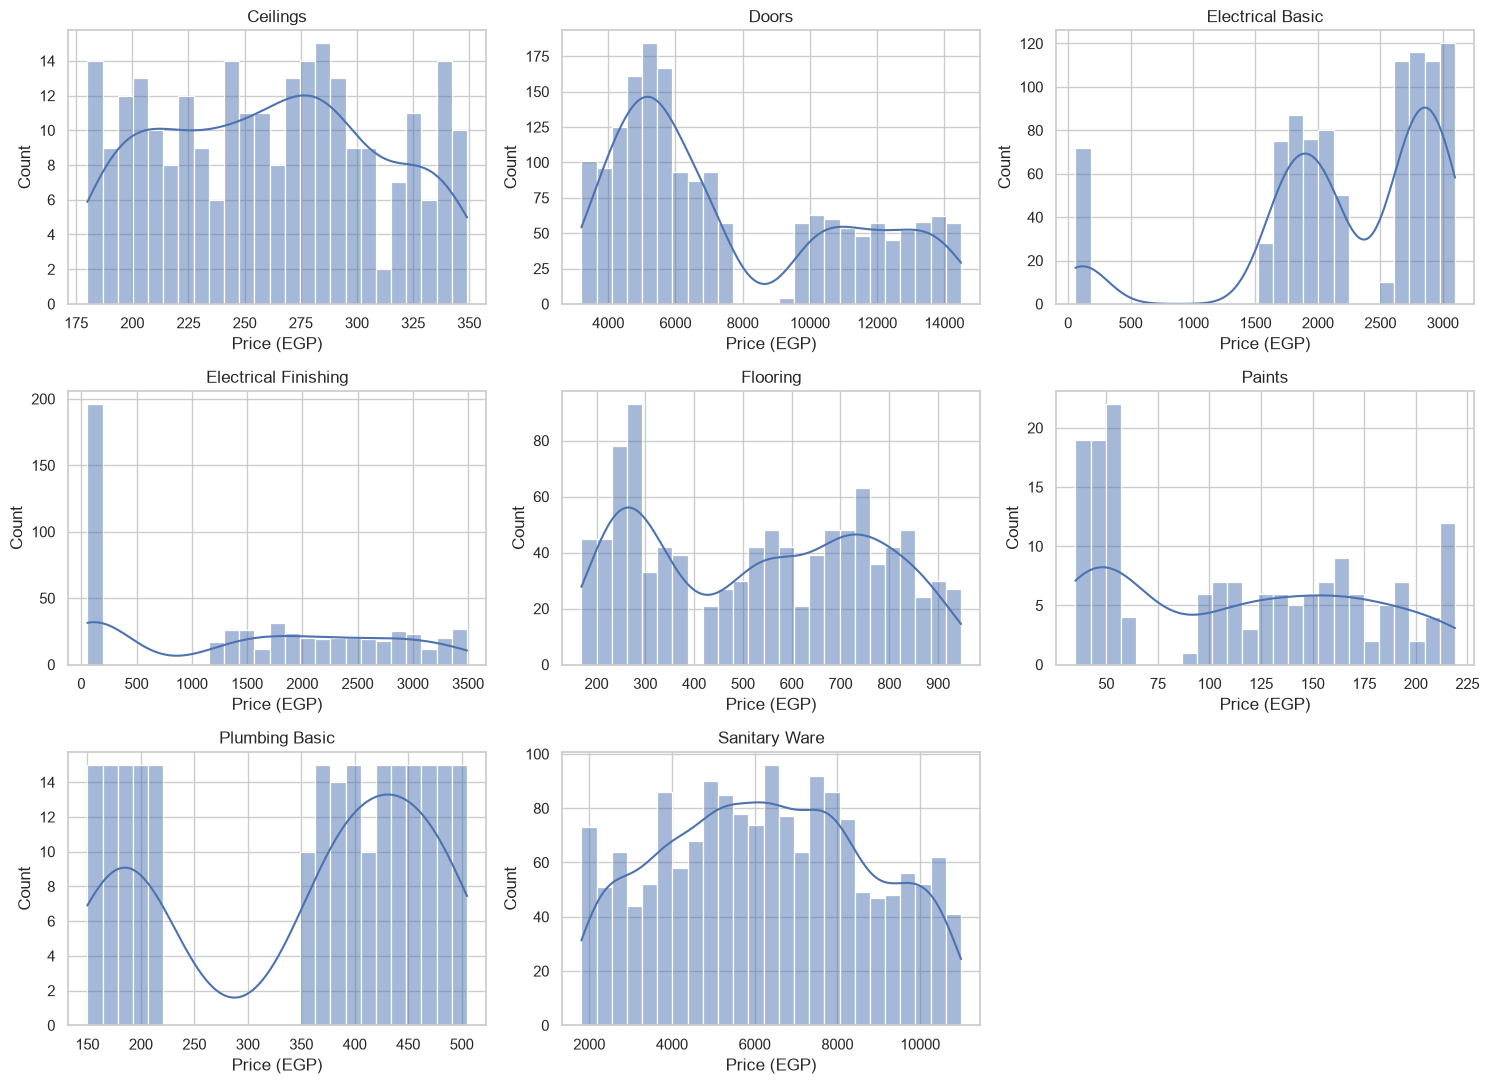

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, (filename, df) in zip(axes.ravel(), raw.items()):
    sns.histplot(df["Price_EGP"], bins=25, kde=True, ax=ax)
    ax.set_title(RAW_CATEGORY_FILES[filename])
    ax.set_xlabel("Price (EGP)")
fig.delaxes(axes.ravel()[-1])
plt.tight_layout()
plt.savefig(Path("..") / "reports" / "figures" / "01_price_distributions.png", dpi=120)
plt.show()

In [9]:
outlier_counts = {}
for filename, df in raw.items():
    flagged = flag_price_outliers(df)
    outlier_counts[filename] = int(flagged["Price_Outlier"].sum())

pd.Series(outlier_counts, name="Flagged_Price_Outliers").to_frame()

,Flagged_Price_Outliers
ceilings_gypsum.csv,0
doors.csv,23
electrical_basic.csv,72
electrical_finishing.csv,11
flooring.csv,0
paints.csv,0
plumbing_basic.csv,5
sanitary_ware.csv,0
labor_and_auxiliary.csv,0


## 10. Audit Conclusions

1. **No missing values** in any core column, and **no zero/negative prices**
   anywhere -- Phase 3 cleaning does not need an imputation strategy for
   `Price_EGP`.
2. **Duplicate rows exist** and are true exact duplicates (verified: every
   column identical, including price) in 7 of the 9 files -- safe to drop.
3. **One vocabulary inconsistency** (`"Bedrooms"` vs `"Bedroom"`) -- fixed in
   cleaning.
4. **`Quality_Level` is already a clean, consistent Low/Medium/High scale**
   across all categories -- no reclassification needed.
5. A modest number of category/quality-specific price outliers exist and are
   flagged for visibility but retained (they reflect legitimate premium
   products, e.g. designer sanitary ware or large security doors).
6. The `All data/` folder is **not** usable as raw input (Section 3) --
   `data/raw/` was populated from each category's own working folder
   instead.

In [10]:
report_path = REPORTS_DIR / "01_data_audit_report.md"
lines = ["# Data Audit Report", ""]
lines.append("Generated by `notebooks/01_Data_Audit.ipynb`. Do not edit by hand.")
lines.append("")
lines.append("## Consolidated summary")
lines.append("")
lines.append(audit_summary.to_markdown(index=False))
lines.append("")
lines.append("## Flagged price outliers (retained, not removed)")
lines.append("")
lines.append(pd.Series(outlier_counts, name='Flagged_Price_Outliers').to_frame().to_markdown())
lines.append("")
lines.append("See the notebook itself for the full narrative (project inventory,")
lines.append("the `All data/` provenance finding, vocabulary checks, and price")
lines.append("distribution plots saved to `reports/figures/01_price_distributions.png`).")

report_path.write_text("\n".join(lines), encoding="utf-8")
print("Saved", report_path)

Saved F:\Instant\DataAnalysis\Gradution Project\All data\_staging\reports\01_data_audit_report.md
